<a href="https://colab.research.google.com/github/sameerkarur/Data_science/blob/main/06_IITK_AIML_Advanced_Generative_AI/demos/Lesson_06_LangChain_for_LLM_Application_Development_Part_2/Demo_01_Langchain_Loader_splitter_embeddings_vectorstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LangChain Loader, Splitter, Embeddings, and VectorStore**

### **Objective:**  
To implement LangChain’s loaders, text splitters, embeddings, and vector stores for efficient document loading, processing, embedding, and similarity search. This activity demonstrates how to handle text and PDF data, create embeddings using Hugging Face and OpenAI models, and perform similarity search using FAISS.

---

### **Note:**  
- Before running any demo, ensure that the **`requirements.txt`** file is installed. This file contains all the required dependencies for **all demos and guided practices under Lessson_6**.
- Install the dependencies using the following command in the terminal: (Run this command twice if the packages are not installed properly)

    **pip install -r requirements.txt**

- The installation process may take around 10- 15 minutes, once installed you select the kernal of that virtual environment 
- If the dependencies were already installed earlier (after creating the virtual environment), there is no need to install them again. You can directly proceed with running the demo.

- Use **Advanced GenAI Lab** for these demos
  
- You will need the following files in your working directory:  
  - `state_of_union.txt` (a sample text document)  
  - `michael_resume.pdf` (a sample PDF resume file)  

---

### **Steps to perform:**
1. Setup the environment
2. Import the necessary modules  
3. Load text data from a file using TextLoader  
4. Load PDFs from the internet using PyPDFLoader  
5. Split the documents using RecursiveCharacterTextSplitter  
6. Embed the documents using HuggingFaceEmbeddings and print the embedding length  
7. Embed the documents using OpenAIEmbeddings and print the embedding length  
8. Create a FAISS instance  
9. Perform a similarity search on the FAISS instance  
10. Persist the FAISS instance  
11. Load the persisted FAISS instance  

---


#### Step 1: Set up the environment 

*   Inside the VM, scroll down and select Terminal

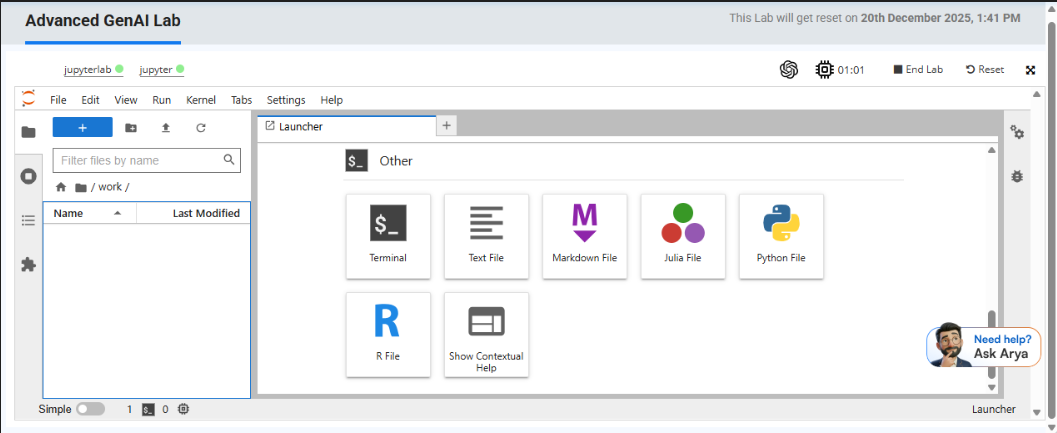

* The Terminal will open in a new tab. Enter the following command inside the terminal to create a virtual environment

    - **python3 -m venv myenv**

    - **source myenv/bin/activate**


* Now, install all the required libraries inside the terminal using the following commands:

    - **pip install ipykernel**

    - **python -m ipykernel install --user --name myenv --display-name "Python (myenv)"**

    - **pip install -r requirements.txt**

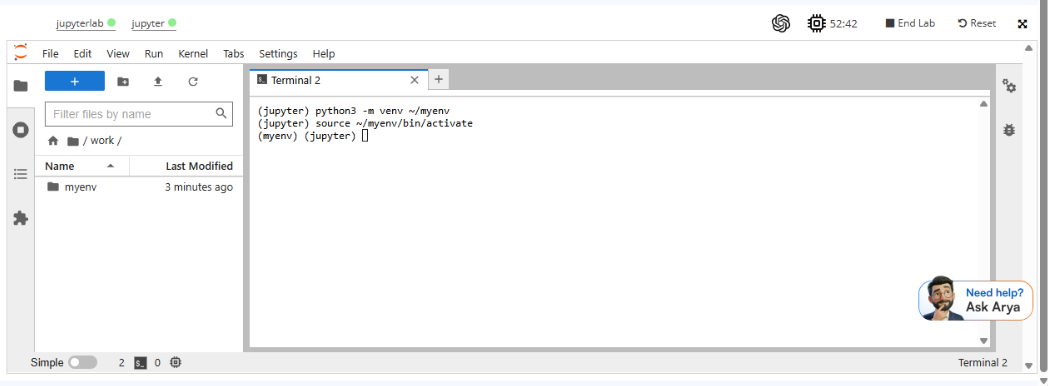


* Click on + to add a new launcher and open a Python notebook. Inside the notebook, go to Kernel and select Change Kernel

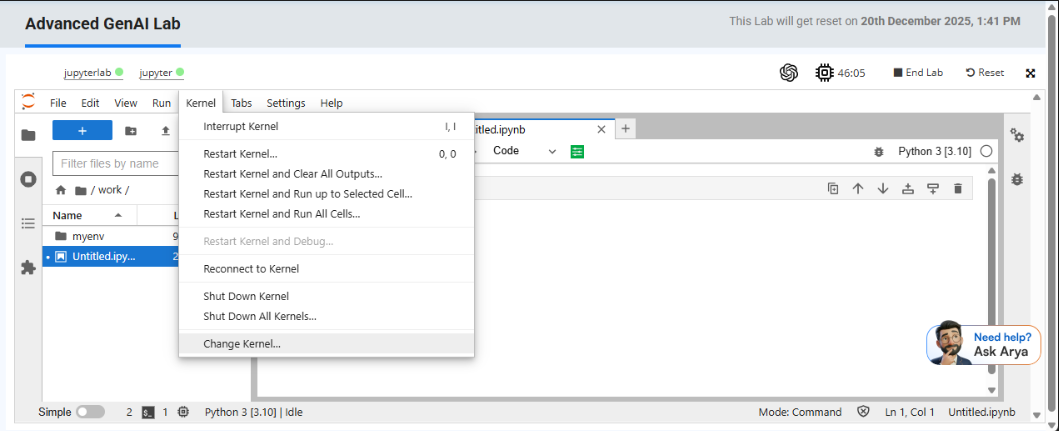

* Choose the Python (myenv) kernel which we created just now

#### Note: Refresh tab and kernel if the kernel name does not appear. It takes some time to load.

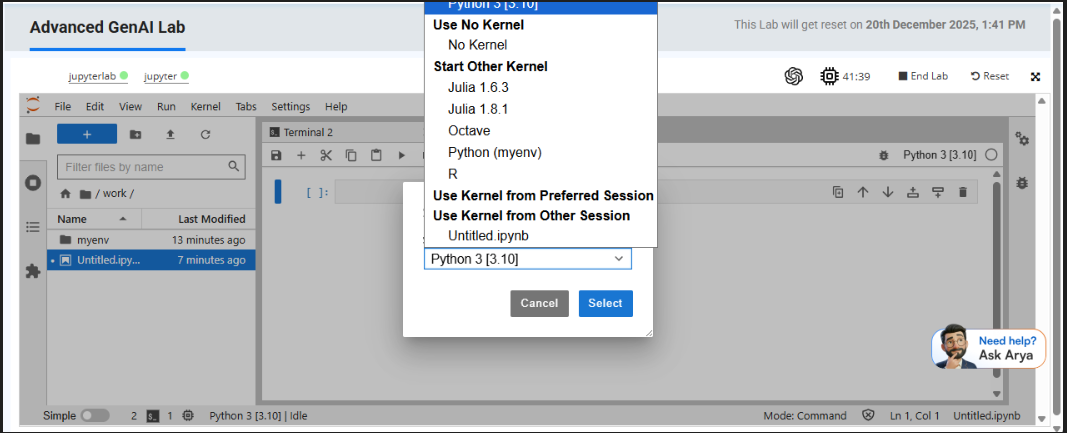


### **Step 2: Import the Necessary Modules**
- Import essential modules from LangChain for document loading, text splitting, embeddings, and vector storage






In [9]:
from langchain_community.document_loaders import TextLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
import faiss

import warnings
warnings.filterwarnings("ignore")

### **Step 2: Load text data from a file using TextLoader**

- Load a plain text file (state_of_union.txt) and print the first 100 characters to confirm successful loading




In [10]:
text_loader = TextLoader("state_of_union.txt")
text_document = text_loader.load()
print(text_document[:100])  # Prints the first 100 characters of the text document

[Document(metadata={'source': 'state_of_union.txt'}, page_content='Madam Speaker, Madam Vice President, our First Lady and Second Gentleman. Members of Congress and the Cabinet. Justices of the Supreme Court. My fellow Americans.  \n\nLast year COVID-19 kept us apart. This year we are finally together again. \n\nTonight, we meet as Democrats Republicans and Independents. But most importantly as Americans. \n\nWith a duty to one another to the American people to the Constitution. \n\nAnd with an unwavering resolve that freedom will always triumph over tyranny. \n\nSix days ago, Russia’s Vladimir Putin sought to shake the foundations of the free world thinking he could make it bend to his menacing ways. But he badly miscalculated. \n\nHe thought he could roll into Ukraine and the world would roll over. Instead he met a wall of strength he never imagined. \n\nHe met the Ukrainian people. \n\nFrom President Zelenskyy to every Ukrainian, their fearlessness, their courage, their determinatio

### **Step 4: Load PDFs from the internet using PyPDFLoader**
- Load a PDF document (e.g., michael_resume.pdf) and split it into pages.
- Print the first page’s content to verify loading.


In [11]:
pdf_loader = PyPDFLoader("michael_resume.pdf")
pdf_pages = pdf_loader.load_and_split()
print(pdf_pages[0])  # Prints the first 100 characters of the first page of the PDF


page_content='CURRICULUM VITAE :  
M ichael M . Scott OBE, B.Sc., Dip.Ed  
 
Home address:  Strome House     Date of Birth: 10.5.51 
   North Strome     Place of Birth: Edinburgh 
   Lochcarron     Married to Sue Scott; 2 stepchildren 
   Ross-shire, IV54 8YJ 
Telephone (work): 01520 722901     Website: www.mmscott.co.uk 
Telephone (home):  01520 722588    E-mail:  MSStrome@aol.com 
 
Awarded OBE in Queen’s Birthday Honours, June 2005, “for services to biodiversity conservation in 
Scotland”. 
Awarded Planta Europa ‘Silver Lead’ Award in September 2007, “for excellent work in European wild plant 
conservation”. 
 
Education 
Primary education: George Heriots School, Edinburgh (1956-1962) 
Secondary education:  Madras College, St Andrews (1962-69). 
Further education: University of Aberdeen (1969-1974): 
    Bachelor of Science (Honours; upper second) in Botany, 1973 
    Diploma of Education, 1974 
   Aberdeen College of Education (1973 - 1974): 
    Certificate of Education in seconda

### **Step 5: Split the documents using RecursiveCharacterTextSplitter**
- Split the loaded PDF into smaller text chunks for processing


In [12]:
doc_splitter = RecursiveCharacterTextSplitter(chunk_size=1024, chunk_overlap=64)
split_texts = doc_splitter.split_documents(pdf_pages)
print(len(split_texts))  # Prints the number of chunks the PDF has been split into


15


- Splitting large documents into smaller chunks helps in efficient embedding and retrieval operations.

### **Step 6: Embed the documents using HuggingFaceEmbeddings and print the length of the embedding**
- Use the Hugging Face embedding model to convert text chunks into numerical vectors



In [13]:
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
hf_embed = HuggingFaceEmbeddings(model_name=MODEL_NAME)
text = split_texts[0].page_content
hf_embed_result = hf_embed.embed_documents([text])
print(len(hf_embed_result[0]))  # Prints the length of the first embedded document

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

768


### **Step 7: Embed the documents using OpenAIEmbeddings and print the length of the embedding**
- Use OpenAIEmbeddings for generating embeddings based on OpenAI’s API


In [14]:
openai_embed = OpenAIEmbeddings()
openai_embed_result = openai_embed.embed_documents([text])
print(len(openai_embed_result[0]))  # Prints the length of the first embedded document


1536


- Embeddings convert textual content into fixed-size dense vectors, useful for similarity search and clustering.

### **Step 8: Create a FAISS instance**
- Create a FAISS (Facebook AI Similarity Search) vector store using the embedded text data

In [15]:
# Create FAISS instance from documents and embeddings
faiss_index = FAISS.from_documents(split_texts, openai_embed)


- FAISS efficiently indexes high-dimensional vectors for similarity retrieval.

### **Step 9: Perform a similarity search on the FAISS instance**
- Perform a similarity search to find documents related to a specific query (e.g., “candidate’s skill sets”)

In [16]:
# Perform a similarity search and print the top two most similar documents
search_result = faiss_index.similarity_search_with_score("What is the candidate's skill sets?", k=2)
for i, (doc, score) in enumerate(search_result, start=1):
    print(f"\n=== Result {i} | Score: {score:.4f} ===")
    print(doc.page_content.strip())



=== Result 1 | Score: 0.4209 ===
Computer knowledge 
I am reasonably fluent in basic PC computer skills, using Windows XP, Word, WordPro, Excel, PowerPoint, 
Adobe Photoshop Elements, e-mail, internet etc.  I have full computer and broadband facilities at home. 
 
Other interests 
Botanising (especially mountain flowers), travel, walking, Scottish islands, gardening, photography, 
computers, rugby supporter, cinema, good wine, Runrig concerts (!). 
 
[updated, 26.03.08]

=== Result 2 | Score: 0.4809 ===
CURRICULUM VITAE :  
M ichael M . Scott OBE, B.Sc., Dip.Ed  
 
Home address:  Strome House     Date of Birth: 10.5.51 
   North Strome     Place of Birth: Edinburgh 
   Lochcarron     Married to Sue Scott; 2 stepchildren 
   Ross-shire, IV54 8YJ 
Telephone (work): 01520 722901     Website: www.mmscott.co.uk 
Telephone (home):  01520 722588    E-mail:  MSStrome@aol.com 
 
Awarded OBE in Queen’s Birthday Honours, June 2005, “for services to biodiversity conservation in 
Scotland”. 
Award

- The FAISS instance returns the most relevant chunks based on cosine similarity scores.

### **Step 10: Persist the FAISS instance**
- Save the FAISS index locally for reuse or sharing

In [17]:
# Save the FAISS index to a file
faiss_index.save_local("faiss_index")


### __Step 11: Load the persisted FAISS instance__
- Reload the FAISS index safely and verify that the stored embeddings can still perform similarity search

In [18]:
# Load the persisted FAISS index from the file safely
faiss_index_loaded = FAISS.load_local(
    "faiss_index", 
    openai_embed,
    allow_dangerous_deserialization=True  # Only safe if you trust the file
)

# Perform a similarity search with the loaded FAISS index
vector_search_result = faiss_index_loaded.similarity_search_with_score(
    "What is the candidate's skill sets?", 
    k=2
)
for i, (doc, score) in enumerate(vector_search_result, start=1):
    print(f"\n=== Result {i} | Score: {score:.4f} ===")
    print(doc.page_content.strip())


=== Result 1 | Score: 0.4209 ===
Computer knowledge 
I am reasonably fluent in basic PC computer skills, using Windows XP, Word, WordPro, Excel, PowerPoint, 
Adobe Photoshop Elements, e-mail, internet etc.  I have full computer and broadband facilities at home. 
 
Other interests 
Botanising (especially mountain flowers), travel, walking, Scottish islands, gardening, photography, 
computers, rugby supporter, cinema, good wine, Runrig concerts (!). 
 
[updated, 26.03.08]

=== Result 2 | Score: 0.4809 ===
CURRICULUM VITAE :  
M ichael M . Scott OBE, B.Sc., Dip.Ed  
 
Home address:  Strome House     Date of Birth: 10.5.51 
   North Strome     Place of Birth: Edinburgh 
   Lochcarron     Married to Sue Scott; 2 stepchildren 
   Ross-shire, IV54 8YJ 
Telephone (work): 01520 722901     Website: www.mmscott.co.uk 
Telephone (home):  01520 722588    E-mail:  MSStrome@aol.com 
 
Awarded OBE in Queen’s Birthday Honours, June 2005, “for services to biodiversity conservation in 
Scotland”. 
Award

- This ensures persistence of vector indexes for scalable retrieval in production environments.

### **Conclusion**

By following these steps, you have successfully implemented LangChain’s Loader, Splitter, Embeddings, and VectorStore functionalities. You learned how to load text and PDF data, split documents into manageable chunks, embed text using different models, store vectors in FAISS, and perform similarity searches for efficient document retrieval.

---